In [2]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]
Interesting_right =   [5, 33, 45, 49]
Interesting_left =   [4, 32, 44, 48]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

data_folder="../Data/"

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, select_regions_Cohen_effect_size, compute_welch
from BCI_Library import saveresults_pickle, select_rows, compute_welch, extract_features_from_spectra_more_bands,cohens_d_per_columm, select_rows


2026-02-04 17:33:45.270013: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 17:33:45.325667: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 17:33:46.593155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
import pandas as pd

Rows = pd.DataFrame({
    "ROIs": [],
    "NROIs":[],
    "DataType": [],
    "freqs_band": [],  
    "subject": [],
    "Classifier": [],
    "Performance": [],
    "Features": [],
    "Comments": [],
    "Date": [],
    "Personalized_Freq_Range":[]
})

Rows.to_pickle("../Results/xxxxx.pkl")

# TEST

In [ ]:
# import os
# import pandas as pd

# folder1 = "../Results/BCI_Performances"


# for filename in os.listdir(folder1):
#     if filename.endswith(".pkl"):
#         file_path = os.path.join(folder1, filename)
        
#         # read dataframe
#         df = pd.read_pickle(file_path)
        
#         # rename column if present
#         if "Comments" in df.columns:
#             df = df.rename(columns={"aasas": "Region Selection"})
#             df["Comments"] = "-"

#         output_path = os.path.join(folder1, filename)
#         df.to_pickle(output_path)


In [ ]:
sys.path.append(os.path.abspath("_Deep_Learning"))


from Utils import freq_filter

In [3]:
import numpy as np
data_2_Rest = read_subject(data_folder, "EEG", "Baseline",2,verbose=False)

data_2_MI = read_subject(data_folder, "EEG", "MI",2,verbose=False)
data = np.concatenate((data_2_Rest, data_2_MI), axis=0)

In [4]:
from scipy.signal import resample_poly
upsampled  = resample_poly(data,2,1,axis=-1)

In [5]:
data.shape, upsampled.shape

((192, 68, 1750), (192, 68, 3500))

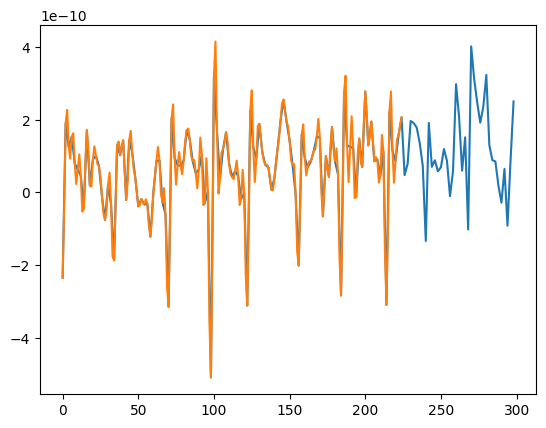

In [19]:
import matplotlib.pyplot as plt
plt.plot([2*_ for  _ in range(150)], data[0,0][0:150])
plt.plot(upsampled[0,0][0:225])

In [1]:
import pandas as pd
pd.read_pickle("../Results/RegionSelection/Selected_regions_Cohen_effect_size_EEG_among_5_folds_training_selected_freq_8_30.pkl")

,Subject,ROIs_fold_1,Effect_size_fold_1,ROIs_fold_2,Effect_size_fold_2,ROIs_fold_3,Effect_size_fold_3,ROIs_fold_4,Effect_size_fold_4,ROIs_fold_5,Effect_size_fold_5,ROIs_All_trials,Effect_size_All_trials
0,0,"(15, 14, 23, 58, 17, 59, 50, 51, 21, 42, 26, 2...","(2.037960067840347, 1.8769264133176342, 1.8761...","(15, 17, 23, 14, 42, 9, 43, 58, 26, 51, 16, 50...","(2.040005232129904, 1.9006648869776948, 1.8496...","(23, 14, 42, 17, 15, 58, 51, 6, 50, 26, 16, 9,...","(1.9802943859788944, 1.9492436600705165, 1.864...","(14, 23, 58, 15, 32, 17, 50, 22, 42, 6, 26, 7,...","(2.0337368979250607, 1.8374658381183153, 1.782...","(14, 15, 42, 23, 17, 58, 7, 16, 9, 26, 50, 6, ...","(2.0319945670837307, 1.9294898345083815, 1.837...","(14, 15, 23, 17, 58, 42, 50, 26, 9, 51, 59, 16...","(1.915491303887696, 1.8966578976792912, 1.8667..."
1,1,"(19, 61, 67, 59, 43, 23, 1, 51, 17, 7, 9, 31, ...","(0.998739823418069, 0.9662281479685884, 0.9488...","(43, 59, 67, 61, 23, 7, 1, 51, 19, 31, 42, 27,...","(0.9542713138129567, 0.9329761737033526, 0.930...","(1, 67, 61, 7, 31, 23, 43, 59, 19, 51, 17, 32,...","(1.0334386127345234, 0.9199514601324457, 0.884...","(67, 61, 1, 43, 59, 23, 19, 17, 7, 31, 25, 51,...","(1.0231979911042095, 0.9931472435949702, 0.947...","(1, 23, 43, 59, 7, 67, 51, 61, 19, 31, 32, 17,...","(0.9597172407159527, 0.9499718779302951, 0.943...","(67, 61, 1, 43, 59, 23, 7, 19, 51, 31, 17, 42,...","(0.944529664340776, 0.9191849012987509, 0.9134..."
2,2,"(32, 14, 50, 44, 33, 62, 48, 4, 47, 34, 35, 43...","(1.857415686578696, 1.7971578125363428, 1.7894...","(32, 44, 33, 14, 50, 48, 62, 4, 47, 45, 34, 21...","(2.0142860594638243, 1.8535705937323568, 1.842...","(44, 32, 14, 48, 50, 33, 62, 4, 34, 47, 27, 35...","(1.887015590550323, 1.8305163875830468, 1.7852...","(32, 33, 62, 44, 14, 50, 48, 47, 4, 46, 34, 45...","(2.028561627376912, 1.8810058143136483, 1.8716...","(32, 33, 14, 44, 50, 47, 62, 48, 4, 46, 15, 34...","(2.044643445877796, 1.8773457971064955, 1.7520...","(32, 44, 14, 33, 50, 62, 48, 4, 47, 34, 46, 35...","(1.9412558098516424, 1.8107556731989527, 1.801..."
3,3,"(7, 22, 15, 51, 23, 48, 50, 32, 59, 43, 6, 45,...","(1.2801198049428164, 1.0724668579420247, 0.869...","(7, 22, 23, 15, 32, 48, 51, 59, 50, 33, 45, 46...","(1.2103134870877923, 1.2097161554655167, 0.944...","(7, 22, 23, 48, 32, 56, 15, 43, 51, 44, 33, 50...","(1.2628926046016022, 1.1927934236011075, 0.864...","(7, 22, 23, 51, 15, 48, 43, 50, 6, 59, 32, 14,...","(1.1773148549863275, 1.1126810189828118, 0.749...","(7, 22, 23, 15, 48, 51, 32, 50, 43, 14, 59, 6,...","(1.2902202225934827, 1.243563870687849, 0.8918...","(7, 22, 23, 15, 51, 48, 32, 50, 43, 6, 33, 59,...","(1.2433947579623705, 1.1649432198005738, 0.847..."
4,4,"(30, 16, 12, 48, 63, 3, 34, 4, 2, 44, 1, 55, 3...","(1.0419679135808548, 1.000682046377755, 0.9169...","(30, 16, 12, 48, 3, 18, 34, 4, 55, 2, 42, 1, 2...","(0.9759719670570653, 0.9202123306129245, 0.910...","(30, 16, 12, 48, 4, 3, 26, 2, 34, 44, 10, 55, ...","(1.0296840379346563, 1.0012777537527098, 0.961...","(30, 16, 12, 3, 48, 4, 34, 2, 55, 10, 32, 26, ...","(1.092368149672131, 1.0400936897314474, 1.0116...","(16, 12, 30, 3, 48, 4, 2, 34, 55, 1, 32, 25, 4...","(0.9900055925782869, 0.9624435287829274, 0.935...","(30, 16, 12, 48, 3, 4, 34, 2, 55, 32, 10, 63, ...","(1.0115241411497546, 0.9663343672852897, 0.928..."
5,5,"(4, 17, 62, 20, 63, 47, 58, 15, 43, 16, 22, 23...","(1.8508138488615813, 1.661527426961607, 1.3642...","(4, 17, 20, 23, 63, 47, 22, 43, 46, 62, 42, 51...","(1.7462278975370886, 1.5059650780195604, 1.327...","(4, 17, 20, 47, 23, 46, 22, 58, 43, 16, 62, 14...","(1.6358344831292162, 1.481376476700179, 1.3450...","(4, 17, 46, 22, 58, 20, 47, 42, 23, 43, 62, 15...","(1.7782265086123499, 1.5688692255574495, 1.344...","(4, 17, 20, 14, 63, 47, 58, 46, 22, 62, 51, 23...","(1.7024065436754183, 1.5328792431397815, 1.282...","(4, 17, 20, 47, 22, 46, 58, 23, 63, 62, 43, 14...","(1.7433088720094458, 1.5440465577055689, 1.276..."
6,6,"(44, 48, 62, 32, 14, 0, 